In [4]:
import pandas as pd 
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [5]:
cust = pd.read_csv("QVI_purchase_behaviour.csv")
trans = pd.read_excel("QVI_transaction_data.xlsx")


In [3]:
display(cust.info())
display(trans.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


None

In [4]:
#initial check for nulls and stuff
print(trans.isna().sum())
print(cust.isna().sum())
print("totsl rows:", len(trans))
print("unique cards:", trans['LYLTY_CARD_NBR'].nunique())
#duplications
trans = trans.drop_duplicates(subset=['TXN_ID', 'PROD_NBR'])

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
totsl rows: 264836
unique cards: 72637


I checked for missing values and confirmed the dataset is clean of nulls. I also counted total transactions and unique customers to get a baseline for the year. Lastly, I removed some duplicate records based on TXN_ID and PROD_NBR just to make sure the data is accurate before merging and doing the actual analysis.

In [5]:
#fixing dates cause excel format is weird
trans['DATE'] = pd.to_datetime(trans['DATE'], unit='D', origin='1899-12-30')

#remove salsa and the huge 200 packet order
trans = trans[~trans['PROD_NAME'].str.lower().str.contains('salsa')]
trans = trans[trans['PROD_QTY'] != 200]

#checking for the missing day
all_days = pd.date_range(start=trans['DATE'].min(), end=trans['DATE'].max())
print("missing date is:", all_days[~all_days.isin(trans['DATE'])])

missing date is: DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')


While checking the data, I found a few issues that needed fixing. First, I converted the dates from Excel's numeric format. I also noticed a huge outlier (Card 226000) who bought 200 packets of chips in a single transaction twice—since this isn't normal "customer" behavior, I removed them to keep the averages clean. I also filtered out "Salsa" products since the focus here is strictly on the chip category. Also found that Dec 25th is missing, which makes sense since stores are closed for Christmas.

In [6]:
# creating brand and pack size columns
trans['PACK_SIZE'] = trans['PROD_NAME'].str.extract('(\d+)').astype(float)
trans['BRAND'] = trans['PROD_NAME'].str.split().str[0]

# merging messy brand names
clean = {'RED': 'RRD', 'Red': 'RRD', 'SNBTS': 'SUNBITES', 'Infzns': 'INFUZIONS', 'WW': 'WOOLWORTHS', 'Smith': 'SMITHS', 'Dorito': 'DORITOS', 'Grain': 'GRNWVES'}
trans['BRAND'] = trans['BRAND'].replace(clean)

In [7]:
# merging everything together
df = pd.merge(trans, cust, on='LYLTY_CARD_NBR', how='left')
df['PRICE'] = df['TOT_SALES'] / df['PROD_QTY']
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,PRICE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium,3.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget,2.10
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget,1.45
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget,3.00
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget,4.60


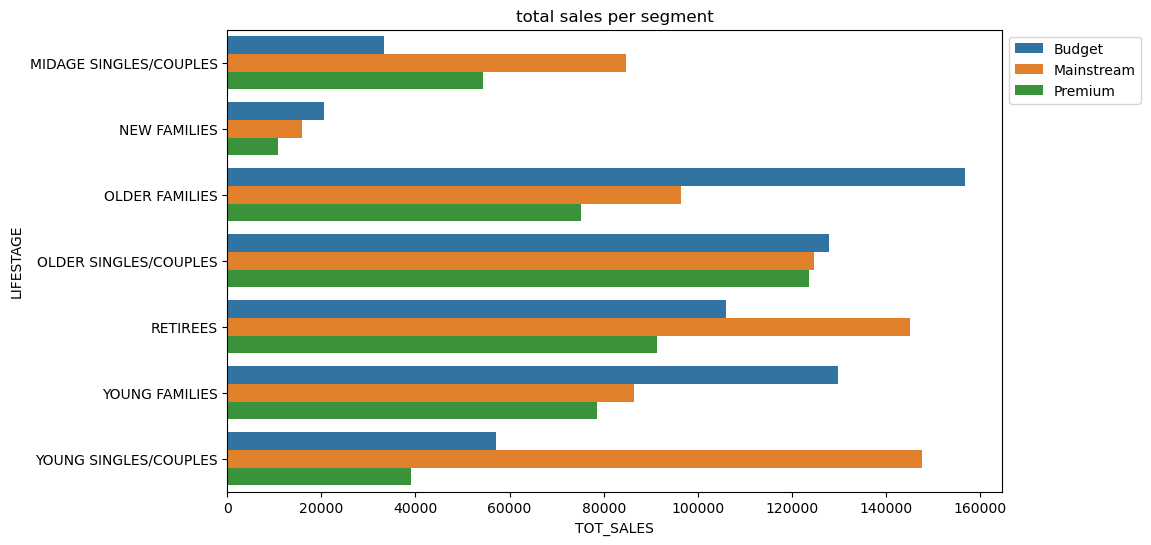

In [8]:
#analysis: ploting sales by segment
sales = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=sales, y='LIFESTAGE', x='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.title("total sales per segment")
plt.show()

In [8]:
print(cust['LIFESTAGE'].value_counts())

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64


To identify which customers drive the most revenue, I grouped total sales by Lifestage and Customer Segment (Budgey, Mainstream, Premium).
Top conttibutors: The highedt sales come from Budget Older Families, Mainstream Young Singles/Couples, and Mainstream Retirees.
Key insight: Mainstream Young Singles/Couples generate very high total sales, making them one of the most valuable segments. Retirees and Older Families also contribute significantly, showing strong spending across multiple lifestages.
Business opportunity: The Maimstream segment consistently performs well, especially among Young Singles/Couples and Retirees, making it a key target for marketing and growth strategies.

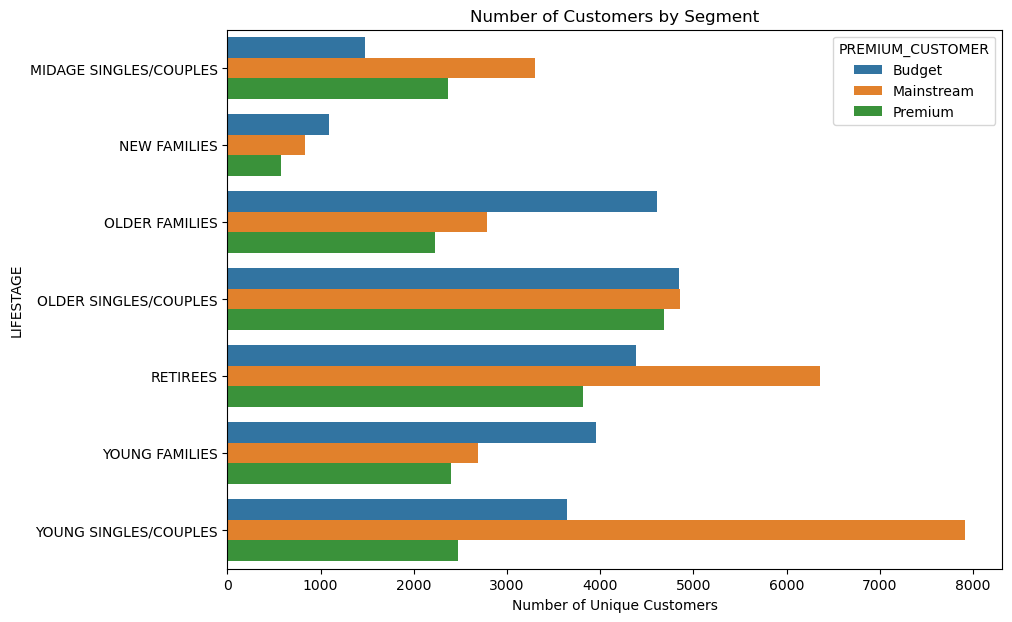

In [9]:
#analysis: nmber of costumers per segment
customer_counts = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()

plt.figure(figsize=(10, 7))
sns.barplot(data=customer_counts, y='LIFESTAGE', x='LYLTY_CARD_NBR', hue='PREMIUM_CUSTOMER')
plt.title('Number of Customers by Segment')
plt.xlabel('Number of Unique Customers')
plt.show()

I grouped customers by lifestage and premium segment to see which groups have the highest number of customers.
The results show that Mainstream Young Singles/Couples, Mainstream Retirees, and Older Singles/Couples have the largest customer counts. This suggests that young singles/couples and retirees make up a big part of the overall customer base.
This also means these segments are important for the business, since a large portion of customers comes from these groups.

/var/folders/rg/z15nbd2x3014zsym_gp48nv40000gn/T/ipykernel_21907/1066696106.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_units = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(


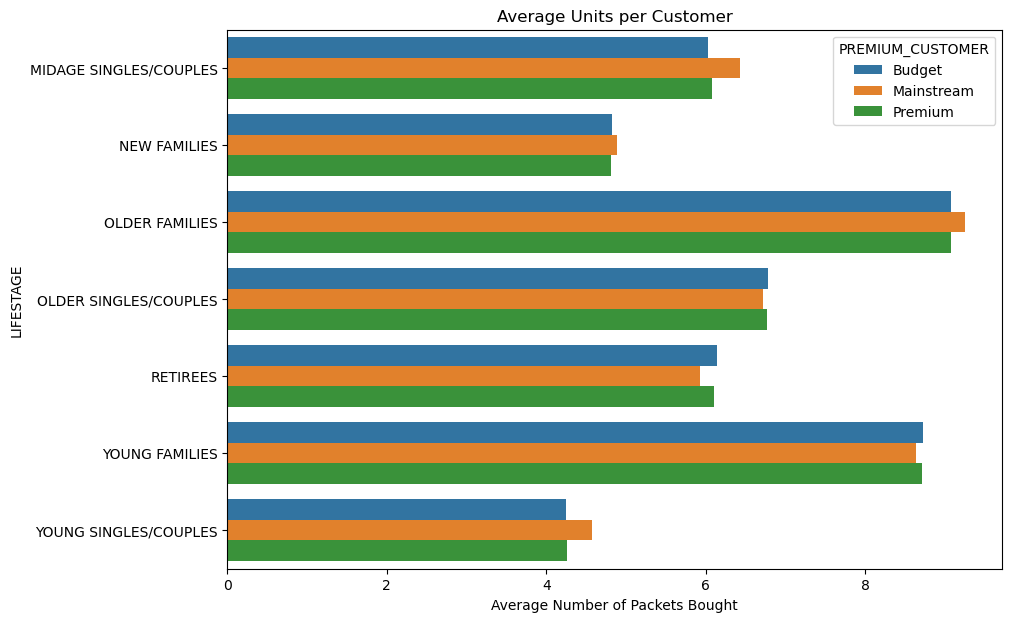

In [10]:
#analysis: average units per culstomer
avg_units = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(
    lambda x: x['PROD_QTY'].sum() / x['LYLTY_CARD_NBR'].nunique()
).reset_index(name='AVG_UNITS')

plt.figure(figsize=(10, 7))
sns.barplot(data=avg_units, y='LIFESTAGE', x='AVG_UNITS', hue='PREMIUM_CUSTOMER')
plt.title('Average Units per Customer')
plt.xlabel('Average Number of Packets Bought')
plt.show()

Next, I looked at the average number of packets bought per customer to understand which segments buy more volume per person.
Key insight: Older Families and Young Families have the highest average units per customer, showing they tend to buy more per purchase. Singles and Couples, on the other hand, buy fewer packets on average.
Conclusion: This means that the high total sales from Singles and Couples is mainly because there are more customers in these segments, not because each customer buys a lot. Families contribute more through higher units per customer, even if their total customer count is lower.

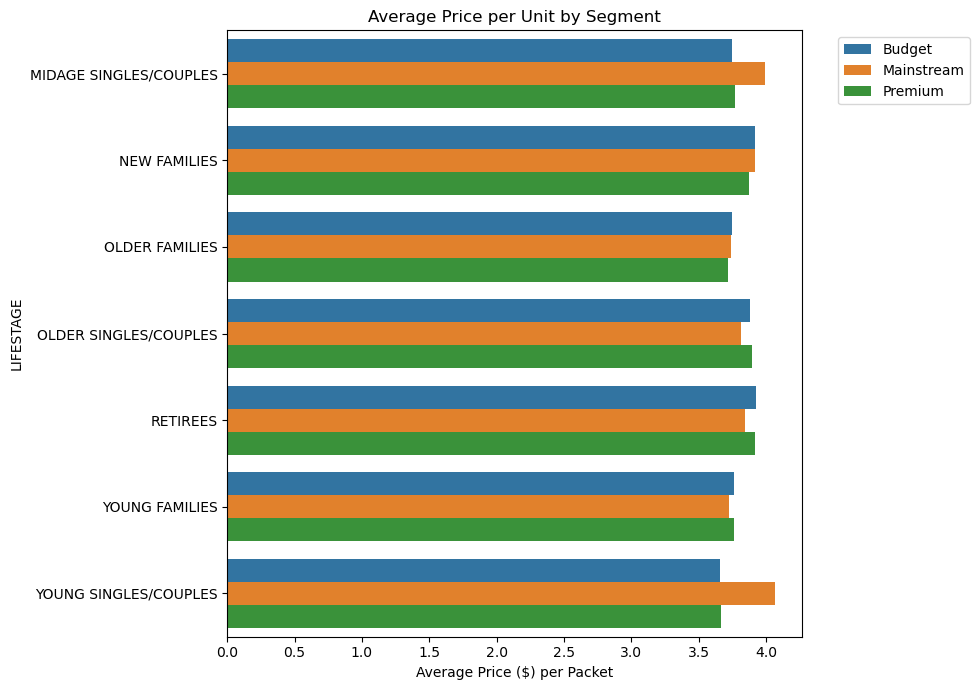

In [11]:
#analysis: average price per unit
avg_price = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE'].mean().reset_index()

plt.figure(figsize=(10, 7))
ax = sns.barplot(data=avg_price, y='LIFESTAGE', x='PRICE', hue='PREMIUM_CUSTOMER')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Average Price per Unit by Segment')
plt.xlabel('Average Price ($) per Packet')
plt.tight_layout() 
plt.show()

I examined the average price per packet to see which segments spend more per unit.
Insight: Mainstream Young and Mid-age Singles/Couples show the highest average price, indicating a preference for more expensive, premium-style products rather than budget options.
Conclusion: This suggests they are less price-sensitive and represent a particularly valuable segment for higher-margin chip products.

In [12]:
# testing if mainstream price difference is real
target_age = ['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']
mainstream = df[(df['LIFESTAGE'].isin(target_age)) & (df['PREMIUM_CUSTOMER'] == 'Mainstream')]['PRICE']
others = df[(df['LIFESTAGE'].isin(target_age)) & (df['PREMIUM_CUSTOMER'] != 'Mainstream')]['PRICE']

t_stat, p_val = stats.ttest_ind(mainstream, others)
print(f"t-test p-value: {p_val}")

if p_val < 0.05:
    print("The difference is statistically significant.")
else:
    print("No significant difference found.")

t-test p-value: 2.235645611549355e-309
The difference is statistically significant.


I ran an independent t-test to see if the higher price paid by the Mainstream Young and Mid-age group is actually a real trend or just a random fluke in the data.
Result: The p-value is basically zero (2.23×10^−309).
Insight: Since the p-value is wayy below 0.05, it means the difference is "statistically signifcant." This confirms that these customers are consistently spending more per bag compared to the budget or premium groups.
Conclusion: We can be pretty confident in targeting this group with more expensive products. Their willingness to pay more is a proven behavior and not just a weird data anomaly.

In [13]:
# finding what brands the target group likes
target_grp = df[(df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (df['PREMIUM_CUSTOMER'] == 'Mainstream')]
others_grp = df[~((df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (df['PREMIUM_CUSTOMER'] == 'Mainstream'))]

brand_affinity = target_grp['BRAND'].value_counts(normalize=True) / others_grp['BRAND'].value_counts(normalize=True)
print(brand_affinity.sort_values(ascending=False).head())

BRAND
Tyrrells    1.235746
Twisties    1.223090
DORITOS     1.223025
Doritos     1.208769
Tostitos    1.205695
Name: proportion, dtype: float64


I wanted to see if the target group (Young Singles/Couples - Mainstream) has a particular "taste" in brands compared to the rest of the customers. I calculated an affinity index to see which brands they're more likely to buy.
Insight: The target group has a really high affinity for Tyrrells, Twisties, and Doritos. For example, they are about 23% more likely to buy Tyrrells chips than the average customer.
Conclusion: This segment prefers "bold" flavors and premium, hand-cooked styles. We should lean into this by featuring these brands in marketing materials or display stands targeted at young adults.

In [14]:
target_pack = target_grp['PACK_SIZE'].value_counts(normalize=True)
other_pack = others_grp['PACK_SIZE'].value_counts(normalize=True)
pack_affinity = (target_pack / other_pack).sort_values(ascending=False)

print("Top Pack Sizes for this group:")
print(pack_affinity.head(5))

Top Pack Sizes for this group:
PACK_SIZE
270.0    1.272264
380.0    1.256843
330.0    1.224472
134.0    1.180998
210.0    1.175541
Name: proportion, dtype: float64


I wanted to see if our target group goes for small "individual" snacks or larger bags. I compared their pack size preferences against the rest of the population to find the "affinity" (basically what they buy way more often than others).
Insight: The target group has a strong preference for 270g, 330g, and 380g packs. They are much more likely to buy these "social" sizes compared to the average customer.
Conclution: Its a bit surprising since they are "singles" and "couples," but it shows they probably buy for parties or social gatherings. Or maybe they just prefer the better value of a bigger bag.
Recommendation: We should avoid promoing small 45g or 90g bags to this group. Instead, we should focus on the 270g range as that is clearly their "sweet spot."